In [1]:
import torch

In [2]:
class LinearLayer:
    def __init__(self, input_dim, output_dim):
        self.input_dim = input_dim
        self.output_dim = output_dim

        self.weights = torch.randn((input_dim, output_dim), dtype=torch.float64, requires_grad=True)
        self.biases = torch.randn((1, output_dim), dtype=torch.float64, requires_grad=True)

    def __call__(self, inputs):
        return self.forward(inputs)

    def forward(self, inputs):
        #inputs: (B, D); weights: (D,LD); Biases: (1, LD)
        output = inputs @ self.weights + self.biases
        return output

    def get_params(self):
        return [self.weights, self.biases]

layer = LinearLayer(5,10)
print(layer.weights.shape)
print(layer.biases.shape)
print(layer.forward(torch.rand((12,5), dtype=torch.float64)).shape)

torch.Size([5, 10])
torch.Size([1, 10])
torch.Size([12, 10])


In [3]:
class LeakyReLU:
    def __init__(self, alpha):
        self.alpha = alpha
    
    def __call__(self, inputs):
        return self.forward(inputs)

    def forward(self, inputs):
        #inputs: (B, D)
        mask = inputs<0
        return torch.where(mask, self.alpha*inputs, inputs)


relu = LeakyReLU(alpha=0.01)
print(relu(torch.tensor([[-1,2,-2]])))

tensor([[-0.0100,  2.0000, -0.0200]])


In [4]:
class Model:
    def __init__(self, input_dim, output_dim, hidden_dim):
        self.input_layer = LinearLayer(input_dim, hidden_dim)
        self.hidden_layer = LinearLayer(hidden_dim, hidden_dim)
        self.output_layer = LinearLayer(hidden_dim, output_dim)

        self.leaky_relu = LeakyReLU(alpha=0.01)

    def __call__(self, inputs):
        return self.forward(inputs)

    def forward(self, inputs):
        #inputs: (B, D);

        output = self.leaky_relu(self.input_layer(inputs))  #(B, HD)
        output = self.leaky_relu(self.hidden_layer(output)) #(B, HD)
        output = self.output_layer(output) #(B, OD)
        return output

    def get_params(self):
        return self.input_layer.get_params() + self.hidden_layer.get_params() + self.output_layer.get_params()

model = Model(3,2,5)
model(torch.rand((10,3), dtype=torch.float64)).shape

torch.Size([10, 2])

In [5]:
class MSE:
    def __init__(self):
        pass

    def __call__(self, gt, pred):
        return self.calculate_loss(gt, pred)
    
    def calculate_loss(self, ground_truth, predicted):
        #(B, D)
        return torch.mean((ground_truth-predicted)**2)


mse = MSE()
mse(torch.tensor([1.,2,3]), torch.tensor([1.,2,5]))

tensor(1.3333)

In [6]:
class GradientDescent:
    def __init__(self, params, alpha):
        self.params = params
        self.alpha = alpha

    def step(self):
        with torch.no_grad():
            for param in self.params:
                if(param.grad is not None):
                    param -= self.alpha * param.grad

    def zero_grad(self):
        for param in self.params:
            if(param.grad is not None):
                param.grad.zero_()
        

In [7]:
from torch.utils.data import DataLoader, Dataset

class SimpleDataset(Dataset):

    def __init__(self, x: torch.Tensor, y: torch.Tensor):
        self.x = x
        self.y = y

    def __len__(self) -> int:
        return len(self.x)

    def __getitem__(self, idx: int) -> tuple[torch.Tensor, torch.Tensor]:
        return (self.x[idx], self.y[idx])

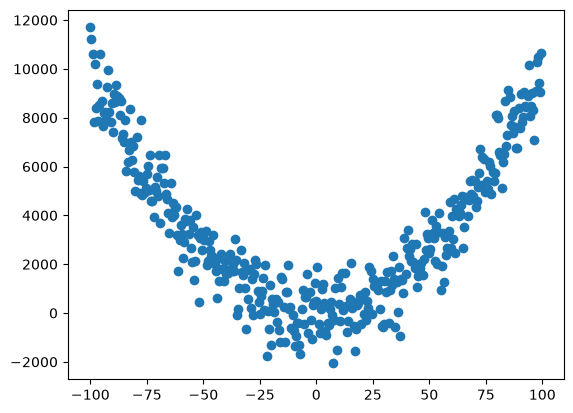

In [8]:
import matplotlib.pyplot as plt


torch.manual_seed(42)
x = torch.arange(-100,100,0.5,requires_grad=True).unsqueeze(1)
y = (x ** 2 + torch.randn(x.shape) * 900).unsqueeze(1)
plt.scatter(x.detach(),y.detach())
plt.show()

100%|██████████| 10000/10000 [00:46<00:00, 213.61it/s]


Final Loss: 0.01872482369995688


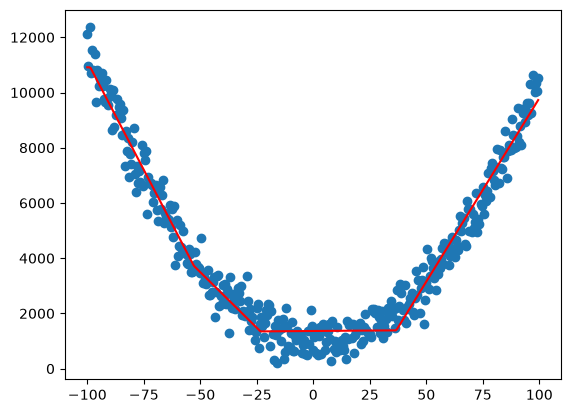

In [9]:
from tqdm import tqdm
import matplotlib.pyplot as plt

def main():
    torch.manual_seed(40)

    x = torch.arange(-100,100,0.5, dtype=torch.float64).unsqueeze(1)
    y = (x ** 2 - 5*x  + 1000 + torch.randn(x.shape, dtype=torch.float64) * 500)
    
    plt.scatter(x,y)

    x_mean, x_std = x.mean(), x.std()
    y_mean, y_std = y.mean(), y.std()

    x_norm = (x - x_mean) / x_std
    y_norm = (y - y_mean) / y_std

    data_loader = DataLoader(SimpleDataset(x_norm,y_norm), batch_size=64, shuffle=True)
    model = Model(input_dim=1, output_dim=1, hidden_dim=4)
    loss_fn = MSE()
    optimizer = GradientDescent(params=model.get_params(), alpha=0.001)

    EPOCHS = 10000

    loss_log = []

    for i in tqdm(range(EPOCHS)):
        for batch in data_loader:
            input, ground_truth = batch #input: (B, 1)
            prediction = model(input)
            loss = loss_fn(gt=ground_truth, pred=prediction)
            loss_log.append(loss.item())
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        # print(f"Epoch {i} completed; loss={loss} ")

    print(f"Final Loss: {loss_log[-1]}")
    with torch.no_grad():
        y_pred = model(x_norm)

    plt.plot(x, y_pred*y_std+y_mean,color="Red")
    # plt.plot(loss_log)
    plt.show()

main()
    